In [1]:
import warnings
warnings.filterwarnings('ignore')
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
from torchsummary import summary
import random
import matplotlib.pyplot as plt
import torchvision.utils as vutils
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, adjusted_rand_score, normalized_mutual_info_score
import json
from tqdm import tqdm
import matplotlib.colors as mcolors
import rasterio
from torch.utils.data import Dataset, DataLoader


<div align="center">

# <span style="color:#2C3E50;">Urban Flood Mapping Using Satellite Synthetic Aperture Radar Data: A Review of Characteristics, Approaches, and Datasets</span>

## <span style="color:#34495E;">Project Details</span>
</div>

| **Field**          | **Information**                                    |
|--------------------|----------------------------------------------------|
| **Course**         | Deep Learning Project                              |
| **Deliverable**    | <span style="color:#16A085;">**Deliverable 2 – Dataset Validation**</span> |
| **Authors**        | Muhammad Sharjeel Nawaz & Syed Moiz Ejaz            |
| **Roll Numbers**   | 28100321 & 28100357                                |

---

## <span style="color:#2980B9;">Dataset Overview</span>

The dataset used for this project is the **UrbanSAR** dataset, hosted on Hugging Face. It consists of:

- **Raw image files** (satellite Synthetic Aperture Radar data) stored in a `train/` folder.
- **Text files** that list image paths, partitioning the data into training and validation splits.

No pre‑made Hugging Face dataset object exists; the dataset must be constructed manually from the provided files.

## <span style="color:#2980B9;">Features</span>

UrbanSARFloods features Sentinel-1 intensity and interferometric coherence image chips (512 × 512), covering 807,500 km² across 5 continents, 20 land cover classes, and 18 flood events. We benchmarked state-of-the-art CNN models and found that imbalanced data and limited training samples remain major challenges, particularly for urban flood detection.

---

## <span style="color:#2980B9;">Dataset Breakdown</span>

| **Validation Metric**               | **Result**                                      |
|--------------------------------------|-------------------------------------------------|
| Total training images                | <span style="color:#27AE60;">4501</span>     |
| Total validation images              | <span style="color:#27AE60;">1970</span>      |
| Consistent image format (all GeoTIFF)| <span style="color:#27AE60;">Pass</span>       |
| Total Number of Channels             | <span style="color:#27AE60;">8</span>          |

## <span style="color:#2980B9;">Channels Discription</span>

| Channel | Category   | Parameter        | Timing     |
|---------|------------|------------------|------------|
| 1       | Coherence  | VH Polarization  | Pre-Flood  |
| 2       | Coherence  | VV Polarization  | Pre-Flood  |
| 3       | Coherence  | VH Polarization  | Post-Flood |
| 4       | Coherence  | VV Polarization  | Post-Flood |
| 5       | Intensity  | VH Polarization  | Pre-Flood  |
| 6       | Intensity  | VV Polarization  | Pre-Flood  |
| 7       | Intensity  | VH Polarization  | Post-Flood |
| 8       | Intensity  | VV Polarization  | Post-Flood |

## Loading the File paths from train and text.txt files

In [2]:
def load_file_list(txt_path):
    with open(txt_path, "r") as f:
        files = [line.strip() for line in f.readlines()]
    return files

train_files = load_file_list("train/urban_sar_floods/Train_dataset.txt")
validate_files = load_file_list("train/urban_sar_floods/Valid_dataset.txt")

In [3]:
root = "train/urban_sar_floods/urban_sar_floods"
def get_paths(file_list):
    image_paths = []
    label_paths = []
    for f in file_list:
        label_path = os.path.normpath(os.path.join(root, f))
        img_path = label_path.replace("GT", "SAR")
        image_paths.append(img_path)
        label_paths.append(label_path)
    return image_paths, label_paths

train_imgs, train_labels = get_paths(train_files)
val_imgs, val_labels = get_paths(validate_files)

## Loading the mean and Standard deviation from norm.txt file

In [4]:
def load_normalize(path):
    mean_in = None
    std_in = None

    with open(path, "r") as f:
        for line in f:
            if "mean_in" in line:
                values = line.split(":")[1].strip().strip("[]")
                mean_in = np.fromstring(values, sep=' ')
            elif "std_in" in line:
                values = line.split(":")[1].strip().strip("[]")
                std_in = np.fromstring(values, sep=' ')

    return mean_in, std_in
mean, std = load_normalize("train/urban_sar_floods/data_norm.txt")

In [5]:
def normalize(img):
        img = img.copy()
        for i in range(8):
            img[i] = (img[i] - mean[i]) / std[i]
        return img

## Visualization of Data

In [6]:
def shape_and_visualize_norm(image_number,cmap):
    img_path = train_imgs[image_number]
    label_path = train_labels[image_number]
    with rasterio.open(img_path) as src:
        img = src.read()
    with rasterio.open(label_path) as src:
        label = src.read(1)
    img = normalize(img)
    plt.figure(figsize=(12,10))
    plt.subplot(3,3,1)
    plt.imshow(label, cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")
    names = ['VH Pre_flood_Coherence', 'VV Pre_flood_Coherence', 'VH Post_flood_Coherence', 'VV Post_flood_Coherence', 'VH Pre_flood', 'VV Pre_flood', 'VH Post_flood', 'VV Post_flood']
    for i in range(8):
        plt.subplot(3,3,i+2)
        plt.title(names[i])
        plt.imshow(img[i],cmap=cmap)
    plt.show()
    print("Image shape:", img.shape)
    print("Label shape:", label.shape)

## Taking Random Samples

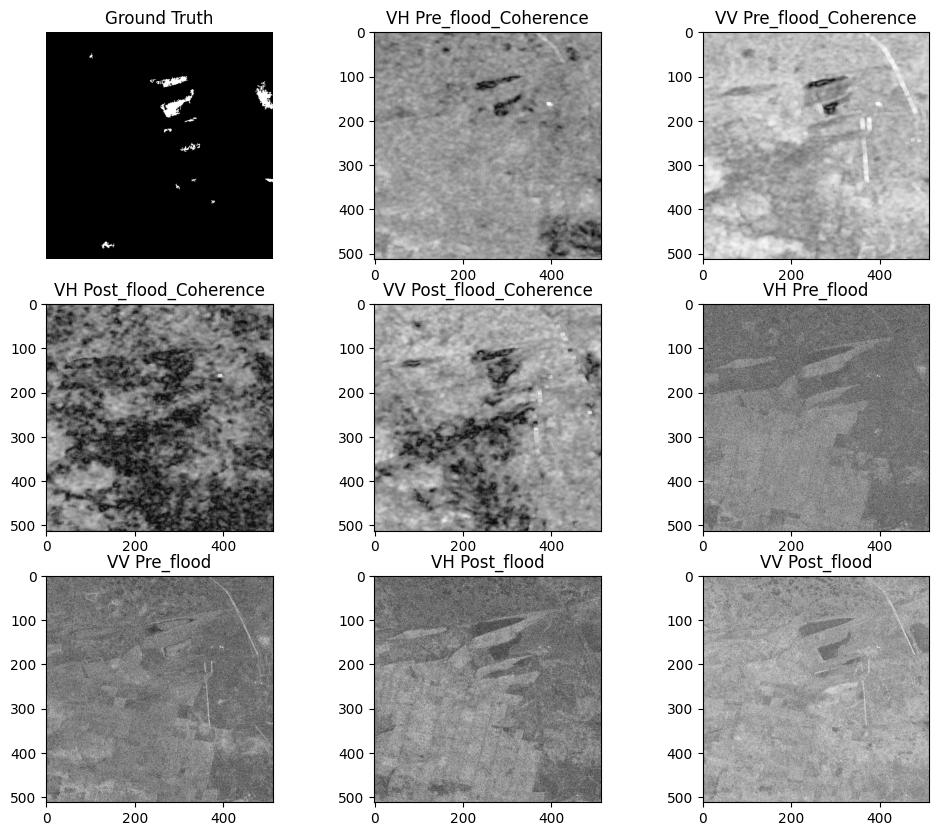

Image shape: (8, 512, 512)
Label shape: (512, 512)


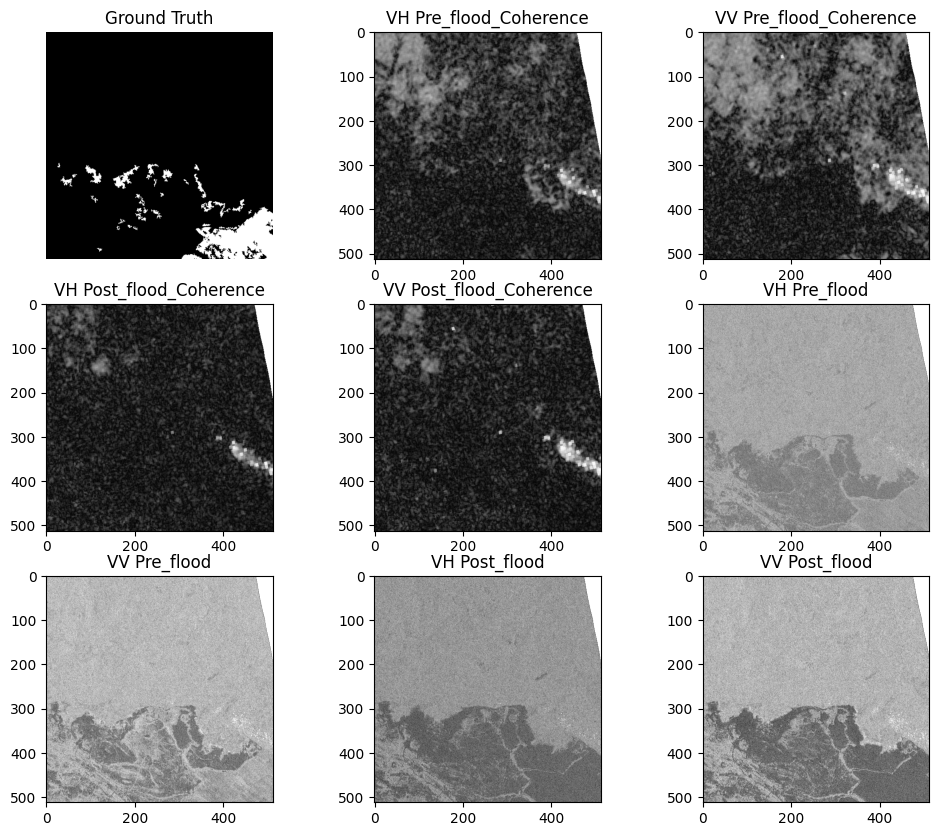

Image shape: (8, 512, 512)
Label shape: (512, 512)


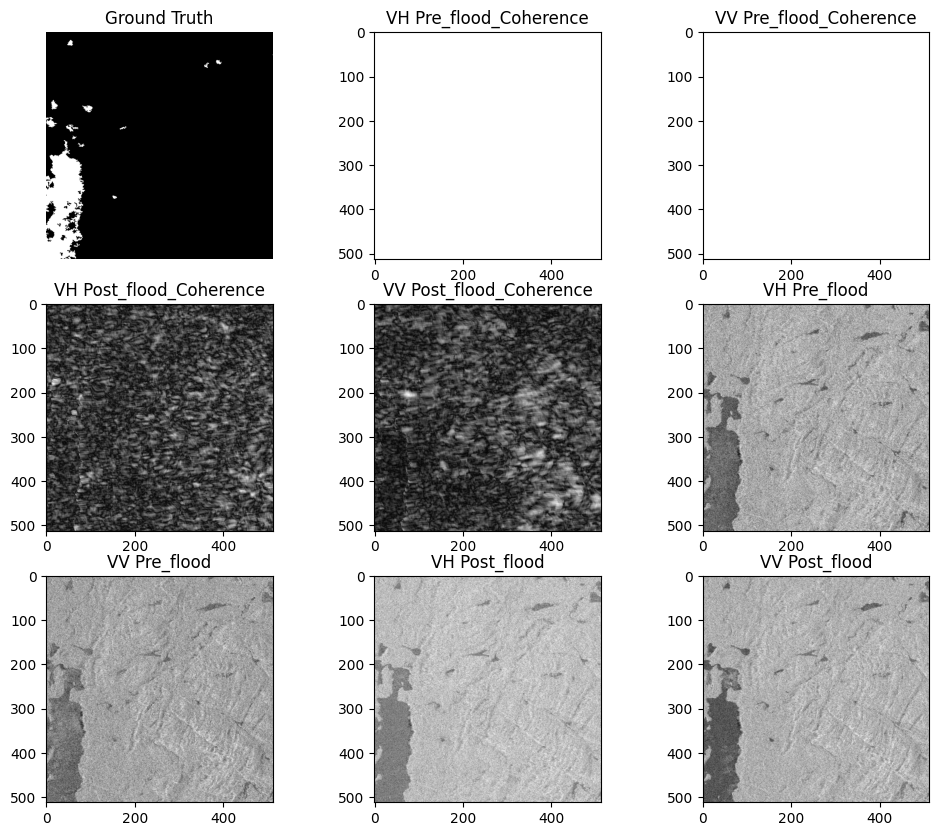

Image shape: (8, 512, 512)
Label shape: (512, 512)


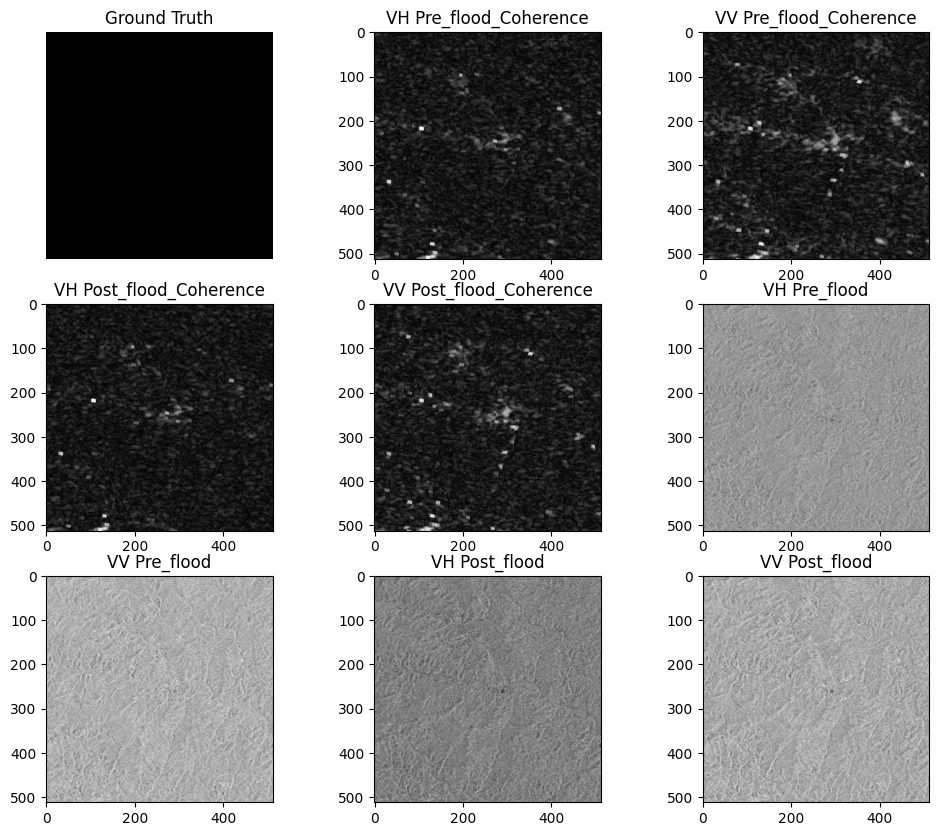

Image shape: (8, 512, 512)
Label shape: (512, 512)


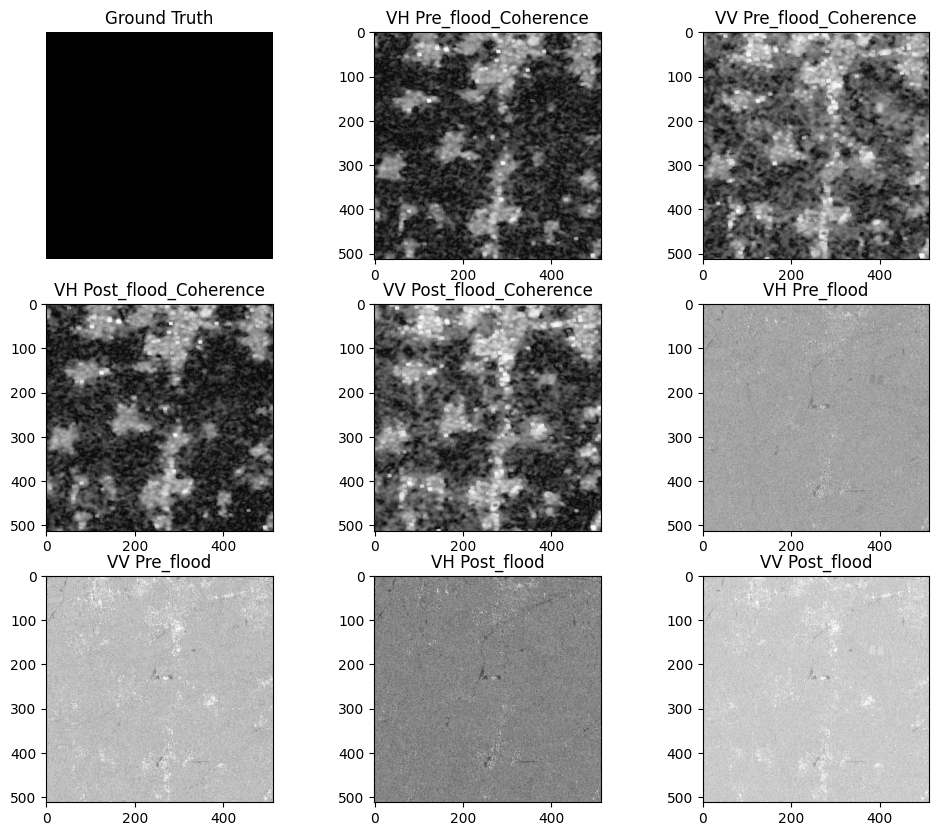

Image shape: (8, 512, 512)
Label shape: (512, 512)


In [7]:
img_num = [553,796,990,1456,2796]
cmap = mcolors.LinearSegmentedColormap.from_list(
    "flood_cmap",
    ["black", "blue", "cyan", "yellow", "red"]
    )
for i in img_num:
    shape_and_visualize_norm(i,'gray')
    # shape_and_visualize_norm(i,cmap)
    

## Building the Dataset and Dataloader

In [8]:
class UrbanSARFloodsDataset(Dataset):
    def __init__(self, img_paths, label_paths, mean, std):
        self.img_paths = img_paths
        self.label_paths = label_paths
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.img_paths)

    def normalize(self, img):
        img = img.copy()
        for i in range(img.shape[0]):
            img[i] = (img[i] - self.mean[i]) / self.std[i]
        return img

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        label_path = self.label_paths[idx]

        with rasterio.open(img_path) as src:
            img = src.read().astype(np.float32)

        with rasterio.open(label_path) as src:
            label = src.read(1).astype(np.float32)

        img = self.normalize(img)
        img = torch.from_numpy(img)
        label = torch.from_numpy(label).long()

        return (img, label)

In [9]:
train_dataset = UrbanSARFloodsDataset(train_imgs,train_labels,mean,std)
img, label = train_dataset[0]
val_dataset = UrbanSARFloodsDataset(val_imgs,val_labels,mean,std)
print("Image shape:", img.shape)
print("Label shape:", label.shape)

Image shape: torch.Size([8, 512, 512])
Label shape: torch.Size([512, 512])


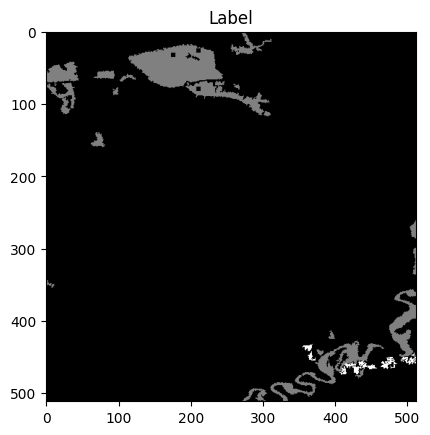

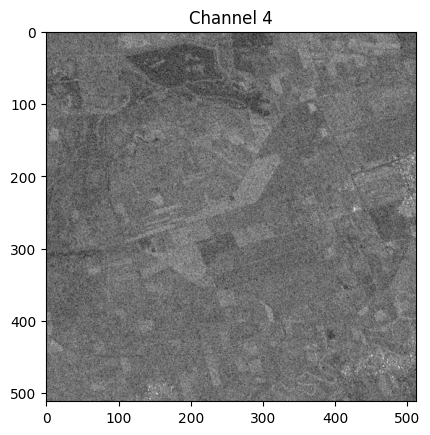

In [10]:
plt.imshow(label.numpy(), cmap='gray')
plt.title("Label")
plt.show()

plt.imshow(img[4].numpy(), cmap='gray')
plt.title("Channel 4")
plt.show()

In [12]:
train_loader = DataLoader(train_dataset,batch_size=64,shuffle=True,num_workers=0)
val_loader = DataLoader(val_dataset,batch_size=64,shuffle=True,num_workers=0)
for imgs, labels in val_loader:
    print("Batch images:", imgs.shape)
    print("Batch labels:", labels.shape)
    break

Batch images: torch.Size([64, 8, 512, 512])
Batch labels: torch.Size([64, 512, 512])
